In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load FEMAtrain.parquet
df_train = pd.read_parquet('FEMAtrain.parquet')

# Load FEMAtest.parquet
df_test = pd.read_parquet('FEMAtest.parquet')

print("FEMAtrain.parquet head:")
display(df_train.head())

print("FEMAtest.parquet head:")
display(df_test.head())

FEMAtrain.parquet head:


,agricultureStructureIndicator,baseFloodElevation,basementEnclosureCrawlspaceType,cancellationDateOfFloodPolicy,condominiumCoverageTypeCode,construction,crsClassCode,buildingDeductibleCode,contentsDeductibleCode,elevatedBuildingIndicator,...,femaRegion,propertyState,reportedCity,reportedZipCode,countyCode,censusTract,censusBlockGroupFips,latitude,longitude,id
0,False,None,NaN,None,N,False,NaN,0,0,True,...,1.0,CT,Currently Unavailable,06475,09007,09007670200,090076702003,41.3,-72.4,b'\xd5$Q\xb8_\xffF{\x9e\x96\xf7\xb0\x84\xf0\xa...
1,False,None,NaN,None,N,False,NaN,5,0,False,...,5.0,OH,Currently Unavailable,45801,39003,39003012400,390030124001,40.8,-84.1,b'\x9a\xc0\x80\x94}\x87C%\x9b?\x00;B\xcf=b'
2,False,None,NaN,None,N,False,NaN,0,0,False,...,4.0,FL,Currently Unavailable,32754,12009,12009060102,120090601022,28.7,-80.9,b'y\x1b\x01J\xb8+B\x9e\xb2\xd7\xf2\r\xcfW4\xd0'
3,False,None,NaN,None,N,False,NaN,1,0,False,...,6.0,OK,Currently Unavailable,73075,40049,40049681300,400496813003,34.7,-97.2,b'\x18\x1da]\xccu@\x18\xa9\x10\xc5\xbf\xc3@\x1...
4,False,None,NaN,None,N,False,NaN,1,1,False,...,9.0,CA,Currently Unavailable,93015,06111,06111000304,061110003042,34.4,-118.9,b'.*\xeb\x1cY\x85C\x01\x86D\xf1\xfe\xa9\xa2\x9...


FEMAtest.parquet head:


,agricultureStructureIndicator,baseFloodElevation,basementEnclosureCrawlspaceType,cancellationDateOfFloodPolicy,condominiumCoverageTypeCode,construction,crsClassCode,buildingDeductibleCode,contentsDeductibleCode,elevatedBuildingIndicator,...,femaRegion,propertyState,reportedCity,reportedZipCode,countyCode,censusTract,censusBlockGroupFips,latitude,longitude,id
0,False,7.00,NaN,None,N,False,NaN,1,None,False,...,4.0,FL,Currently Unavailable,33012,12086,12086000710,120860007101,25.8,-80.3,b'\x9a\x98\xc5\xea\xa7\xb9A\x9f\xb4\x89l\x9dA\...
1,False,7.00,NaN,2009-05-19,N,False,NaN,0,0,False,...,4.0,NC,Currently Unavailable,28557,37031,37031970501,370319705012,34.7,-76.8,b'\xeak\xed\xfd\x1c\x02L\xb7\xb6\\o\xc5i\xf4;:'
2,False,12.00,1.0,None,N,False,NaN,1,1,True,...,4.0,NC,Currently Unavailable,27927,37053,37053110101,370531101012,36.3,-75.8,b'\xdec\xe2\xb1tLFa\x8a<i?\x86:\xbd\xe8'
3,False,12.00,2.0,None,N,False,NaN,0,None,True,...,4.0,NC,Currently Unavailable,28449,37129,37129012203,371290122031,34.0,-77.9,"b""=\x85\x9f\xed'UI\xe9\xbf\x9ft\x17\x94p\x13i"""
4,False,None,1.0,None,N,False,NaN,0,0,False,...,2.0,NJ,Currently Unavailable,07508,34031,34031133702,340311337021,40.9,-74.2,b'\xf5\xe8\xae\x9a\x16[G\xd8\xb2\xfd]\xbbn\xee...


In [2]:
# Check for duplicate rows
train_duplicates = df_train.duplicated().sum()
test_duplicates = df_test.duplicated().sum()

print(f"Number of duplicate rows in FEMAtrain: {train_duplicates}")
print(f"Number of duplicate rows in FEMAtest: {test_duplicates}")

Number of duplicate rows in FEMAtrain: 0
Number of duplicate rows in FEMAtest: 0


In [3]:
# DISPLAY MISSING VALUE RATIOS
column_names = df_train.columns
column_types = df_train.dtypes
column_name_type = dict(zip(column_names, column_types))
train_na_ratio = (df_train.isna().sum() / len(df_train))
test_na_ratio = (df_test.isna().sum() / len(df_test))

na_data = []
for col_name in column_name_type.keys():
    col_type = str(column_name_type.get(col_name, 'Unknown Type'))
    train_ratio = train_na_ratio.get(col_name, -1)
    test_ratio = test_na_ratio.get(col_name, -1)
    na_data.append({'Column Name': col_name, 'Type': col_type, 'Train NA Ratio': train_ratio, 'Test NA Ratio': test_ratio})

# Create DataFrame and sort by Train NA Ratio
df_na_summary = pd.DataFrame(na_data).sort_values(by='Train NA Ratio', ascending=False)

# Ensure all columns (rows in this view) are displayed
with pd.option_context('display.max_rows', None):
    display(df_na_summary)

,Column Name,Type,Train NA Ratio,Test NA Ratio
3,cancellationDateOfFloodPolicy,object,0.957866,0.957516
38,cancellationVoidanceReasonCode,object,0.957866,0.957516
21,obstructionType,float64,0.815704,0.815644
10,elevationCertificateIndicator,object,0.782403,0.782163
49,enclosureTypeCode,object,0.748483,0.749167
51,insuranceToValueCode,float64,0.706809,0.706405
17,lowestAdjacentGrade,object,0.688930,0.690803
18,lowestFloorElevation,object,0.672073,0.673389
1,baseFloodElevation,object,0.667099,0.668553
11,elevationDifference,float64,0.663041,0.664487


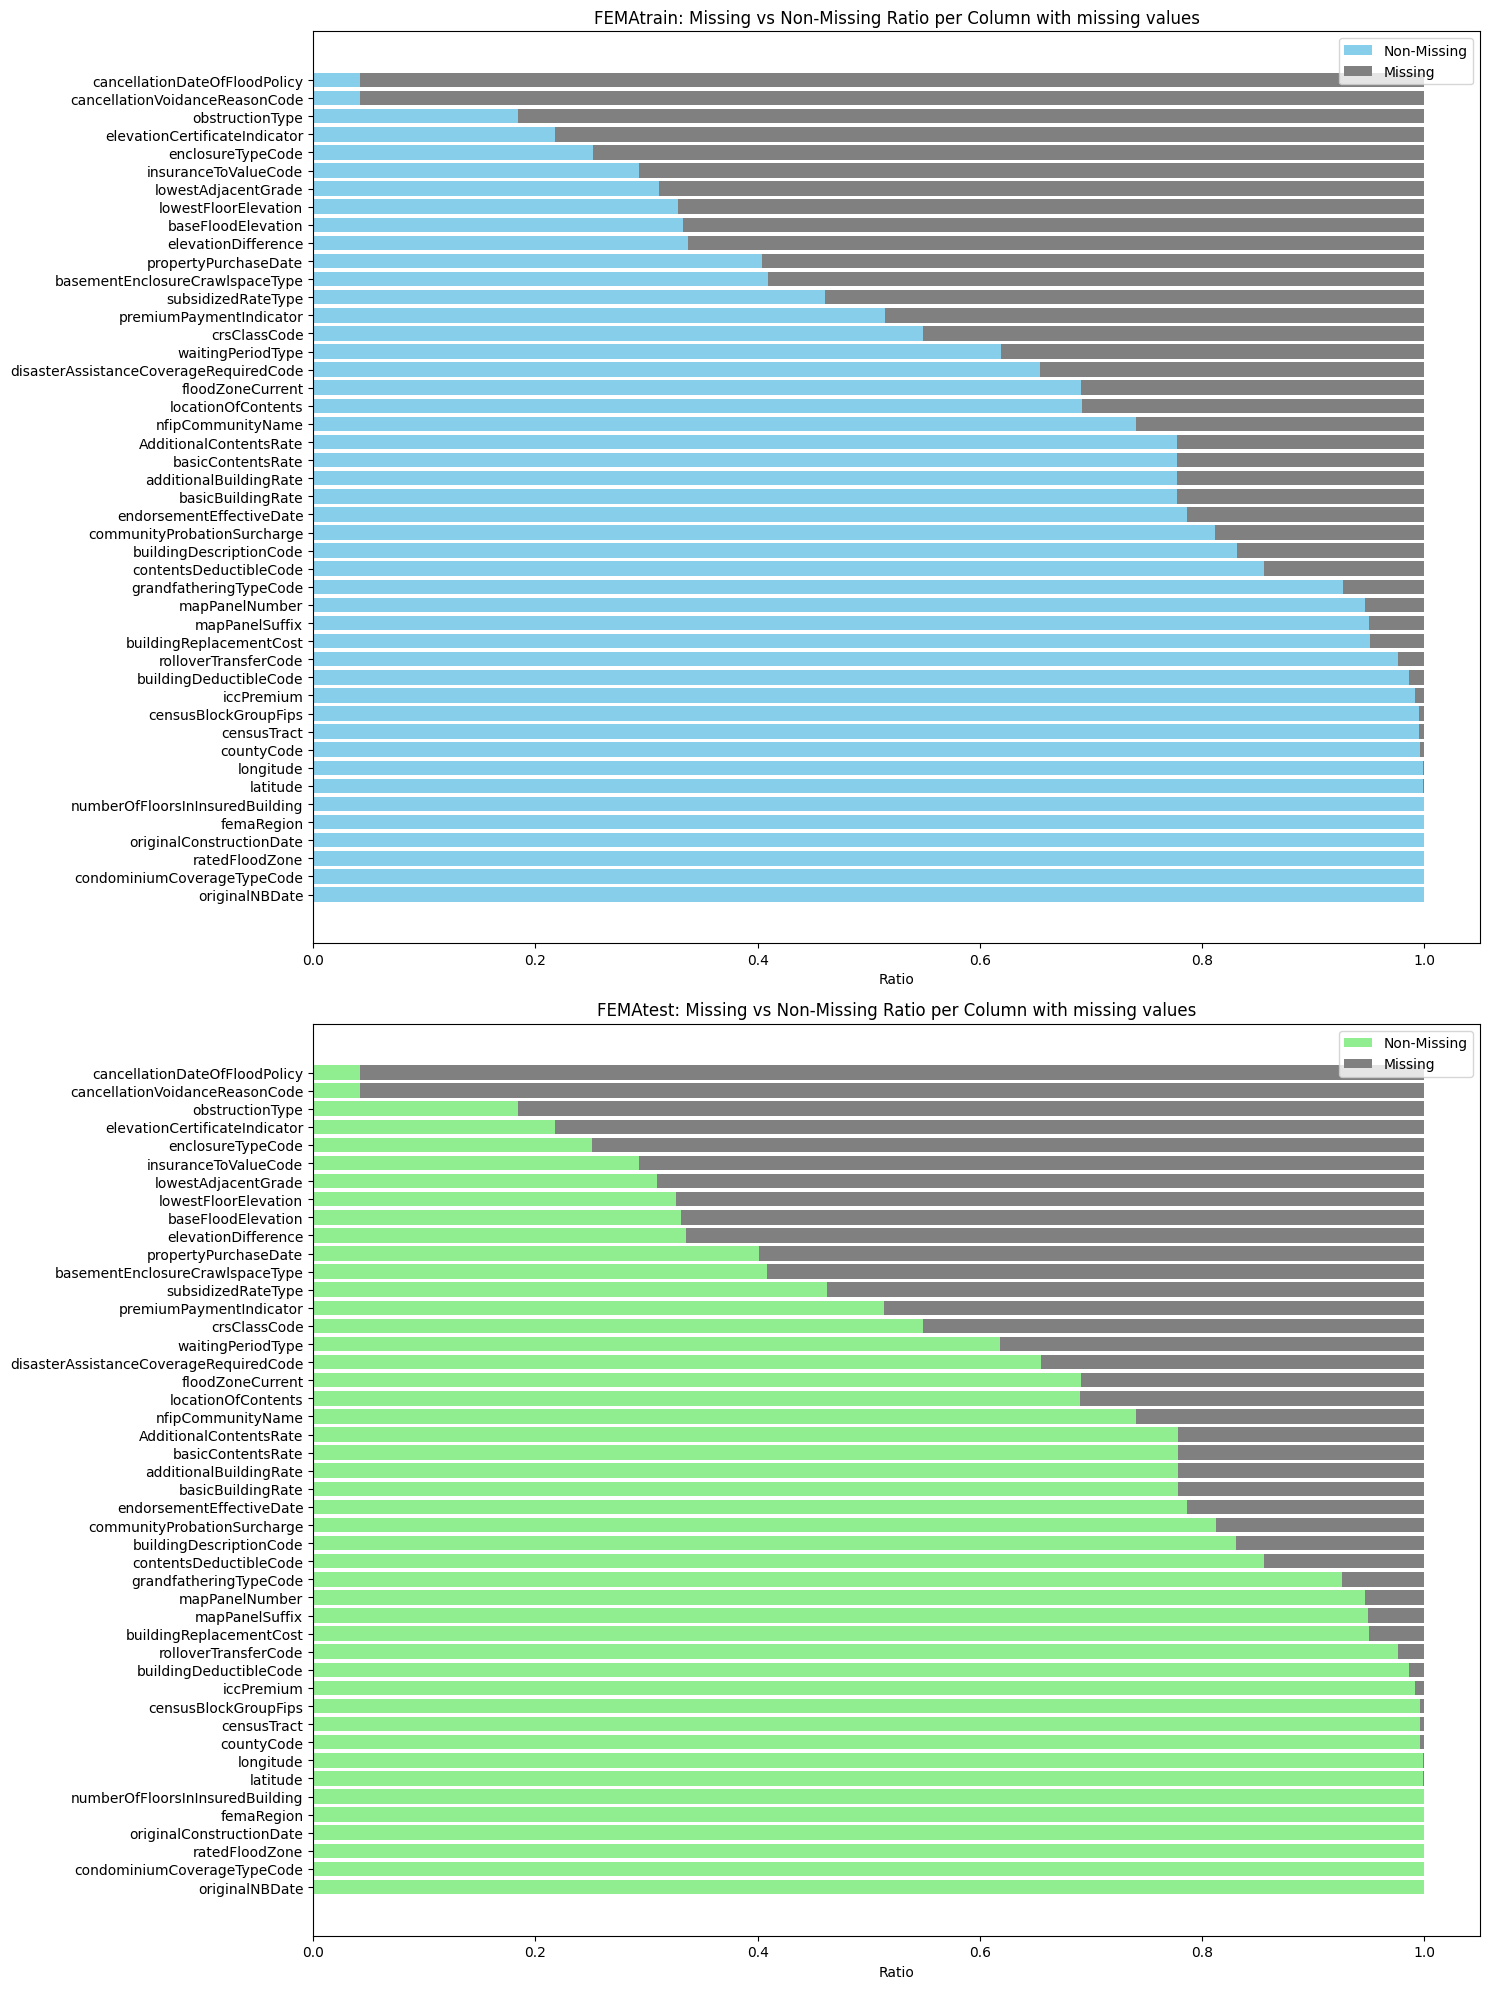

In [4]:
# Filter for columns that have missing values to keep the charts readable
cols_with_na = df_na_summary[df_na_summary['Train NA Ratio'] > 0]['Column Name'].tolist()

# Prepare data for Train
train_na = np.array([train_na_ratio[col] for col in cols_with_na])
train_valid = 1 - train_na

# Prepare data for Test
test_na = np.array([test_na_ratio[col] for col in cols_with_na])
test_valid = 1 - test_na

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 20))

# Horizontal Stacked Bar for Train
ax1.barh(cols_with_na, train_valid, label='Non-Missing', color='skyblue')
ax1.barh(cols_with_na, train_na, left=train_valid, label='Missing', color='gray')
ax1.set_title('FEMAtrain: Missing vs Non-Missing Ratio per Column with missing values')
ax1.set_xlabel('Ratio')
ax1.invert_yaxis()  # Invert to read top to bottom
ax1.legend()

# Horizontal Stacked Bar for Test
ax2.barh(cols_with_na, test_valid, label='Non-Missing', color='lightgreen')
ax2.barh(cols_with_na, test_na, left=test_valid, label='Missing', color='gray')
ax2.set_title('FEMAtest: Missing vs Non-Missing Ratio per Column with missing values')
ax2.set_xlabel('Ratio')
ax2.invert_yaxis()
ax2.legend()

plt.tight_layout()
plt.show()

1. Decide which columns to keep
    1. I want columns with less than 5% missing values, except
        1. `regularEmergencyProgramIndicator` is redundant because we already have `programTypeIndicator`
        2. `censusTract`, `censusBlockGroupFips`, `countyCode`, `latitude`, `longitude`, `femaRegion` have missing values and provide location info that I don't need (I already have `propertyState`, `reportedZipCode` which don't have missing values)
    2. Therefore, I want columns without missing values, as well as `buildingReplacementCost`, `rolloverTransferCode`, `buildingDeductibleCode`, `iccPremium`, `numberOfFloorsInInsuredBuilding`, `originalConstructionDate`, `ratedFloodZone`, `condominiumCoverageTypeCode`, `originalNBDate`
2. Convert dtypes when necessary
    1. `originalConstructionDate`, `originalNBDate`, `policyEffectiveDate`, `policyTerminationDate` are dates
    2. `numberOfFloorsInInsuredBuilding`, `occupancyType` are categorical (among others)

In [5]:
keep = train_na_ratio[train_na_ratio == 0].index.tolist() + ["buildingReplacementCost", "rolloverTransferCode", "buildingDeductibleCode", "iccPremium", "numberOfFloorsInInsuredBuilding", "originalConstructionDate", "ratedFloodZone", "condominiumCoverageTypeCode", "originalNBDate"]
drop = [col for col in df_train.columns if col not in keep]
drop.append("regularEmergencyProgramIndicator")
df_train.drop(columns=drop, inplace=True)
df_test.drop(columns=drop, inplace=True)

In [6]:
# some of the oldest dates cannot be converted to datetime and must be coerced to NaT
def convert_to_date(df):
    df["originalConstructionDate"] = pd.to_datetime(df["originalConstructionDate"], errors="coerce")
    df["originalNBDate"] = pd.to_datetime(df["originalNBDate"], errors="coerce")
    df["policyEffectiveDate"] = pd.to_datetime(df["policyEffectiveDate"], errors="coerce")
    df["policyTerminationDate"] = pd.to_datetime(df["policyTerminationDate"], errors="coerce")
convert_to_date(df_train)
convert_to_date(df_test)

In [7]:
def convert_to_category(df):
    df["condominiumCoverageTypeCode"] = df["condominiumCoverageTypeCode"].astype("category")
    df["buildingDeductibleCode"] = df["buildingDeductibleCode"].astype("category")
    df["ratedFloodZone"] = df["ratedFloodZone"].astype("category")
    df["numberOfFloorsInInsuredBuilding"] = df["numberOfFloorsInInsuredBuilding"].astype("category")
    df["occupancyType"] = df["occupancyType"].astype("category")
    df["rateMethod"] = df["rateMethod"].astype("category")
    df["rolloverTransferCode"] = df["rolloverTransferCode"].astype("category")
    df["nfipRatedCommunityNumber"] = df["nfipRatedCommunityNumber"].astype("category")
    df["nfipCommunityNumberCurrent"] = df["nfipCommunityNumberCurrent"].astype("category")
    df["propertyState"] = df["propertyState"].astype("category")
    df["reportedCity"] = df["reportedCity"].astype("category")
    df["reportedZipCode"] = df["reportedZipCode"].astype("category")
convert_to_category(df_train)
convert_to_category(df_test)


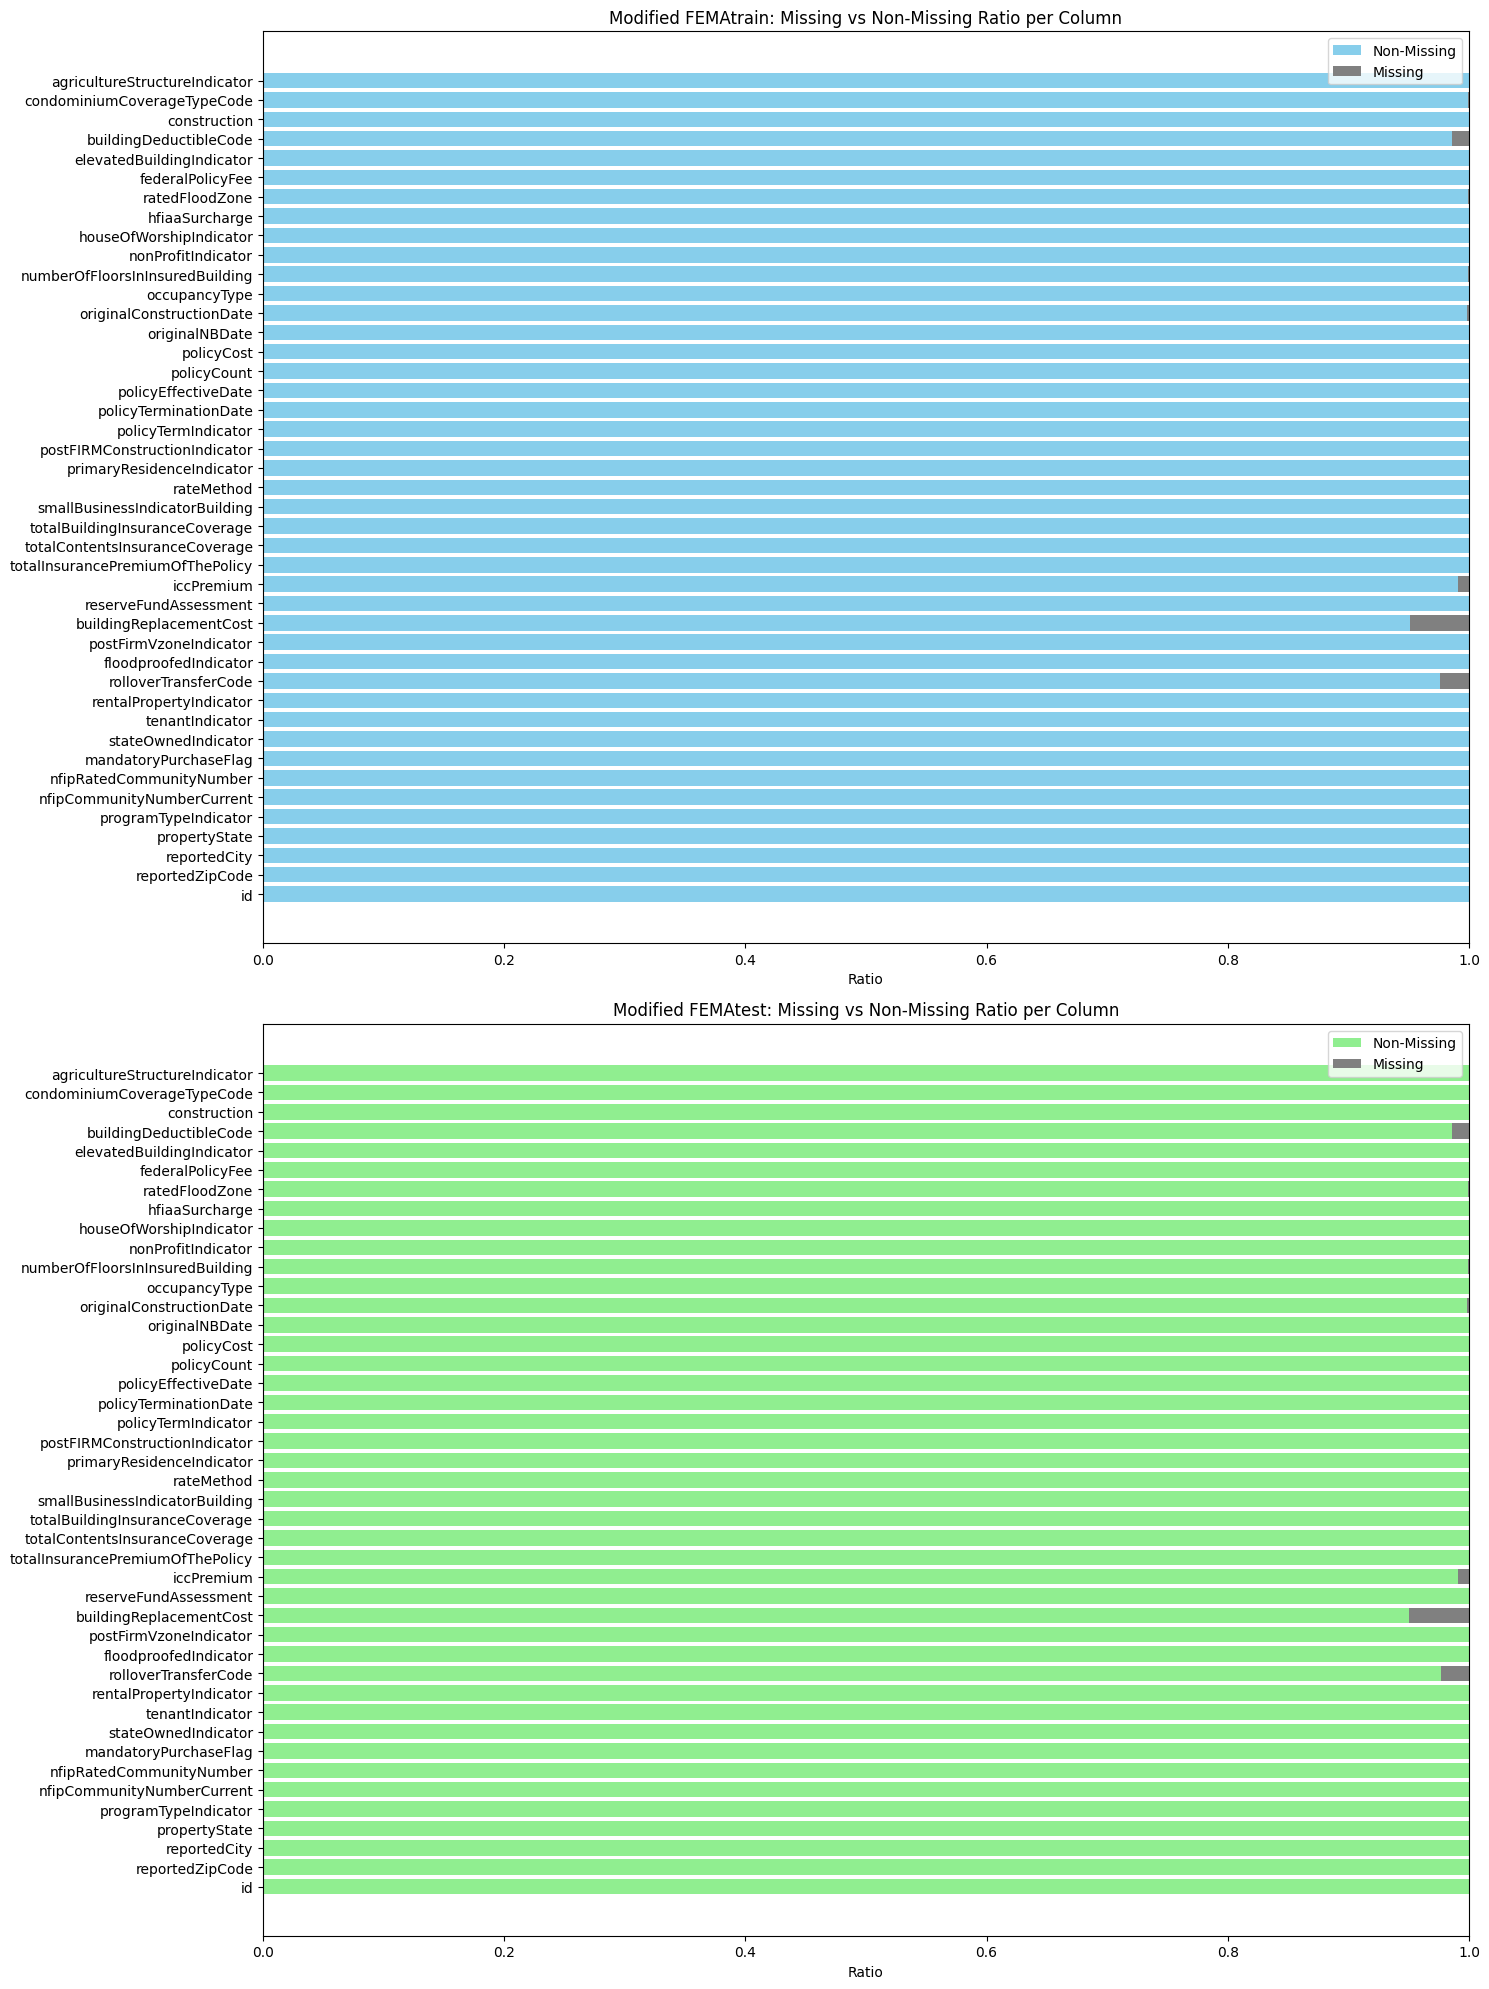

In [8]:
# Calculate NA ratios for the current modified dataframes
current_train_na = df_train.isna().sum() / len(df_train)
current_test_na = df_test.isna().sum() / len(df_test)

# Get the list of columns currently in the modified dataframes
modified_cols = df_train.columns.tolist()

# Prepare data for Train
train_na_vals = current_train_na.values
train_valid_vals = 1 - train_na_vals

# Prepare data for Test
test_na_vals = current_test_na.values
test_valid_vals = 1 - test_na_vals

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 20))

# Horizontal Stacked Bar for Train
ax1.barh(modified_cols, train_valid_vals, label='Non-Missing', color='skyblue')
ax1.barh(modified_cols, train_na_vals, left=train_valid_vals, label='Missing', color='gray')
ax1.set_title('Modified FEMAtrain: Missing vs Non-Missing Ratio per Column')
ax1.set_xlabel('Ratio')
ax1.invert_yaxis()
ax1.legend()

# Horizontal Stacked Bar for Test
ax2.barh(modified_cols, test_valid_vals, label='Non-Missing', color='lightgreen')
ax2.barh(modified_cols, test_na_vals, left=test_valid_vals, label='Missing', color='gray')
ax2.set_title('Modified FEMAtest: Missing vs Non-Missing Ratio per Column')
ax2.set_xlabel('Ratio')
ax2.invert_yaxis()
ax2.legend()

plt.tight_layout()
plt.show()

3. Describe and plot
    1. Boolean -> describe summary statistics, plot horizontal stacked bar charts
    2. Categorical -> describe summary statistics, plot horizontal bar charts
    2. Dates -> describe summary statistics, plot histograms
    3. Numerical -> describe summary statistics, plot boxplots

Boolean feature distribution in FEMAtrain:


,Column,True_Ratio,False_Ratio
0,agricultureStructureIndicator,0.000546,0.999454
1,construction,0.002172,0.997828
2,elevatedBuildingIndicator,0.169051,0.830949
3,houseOfWorshipIndicator,0.001222,0.998778
4,nonProfitIndicator,0.003503,0.996497
5,postFIRMConstructionIndicator,0.534328,0.465672
6,primaryResidenceIndicator,0.706764,0.293236
7,smallBusinessIndicatorBuilding,0.013973,0.986027
8,postFirmVzoneIndicator,0.001449,0.998551
9,floodproofedIndicator,0.000095,0.999905



Boolean feature distribution in FEMAtest:


,Column,True_Ratio,False_Ratio
0,agricultureStructureIndicator,0.000547,0.999453
1,construction,0.002156,0.997844
2,elevatedBuildingIndicator,0.169151,0.830849
3,houseOfWorshipIndicator,0.001290,0.998710
4,nonProfitIndicator,0.003521,0.996479
5,postFIRMConstructionIndicator,0.535207,0.464793
6,primaryResidenceIndicator,0.705309,0.294691
7,smallBusinessIndicatorBuilding,0.014049,0.985951
8,postFirmVzoneIndicator,0.001514,0.998486
9,floodproofedIndicator,0.000084,0.999916


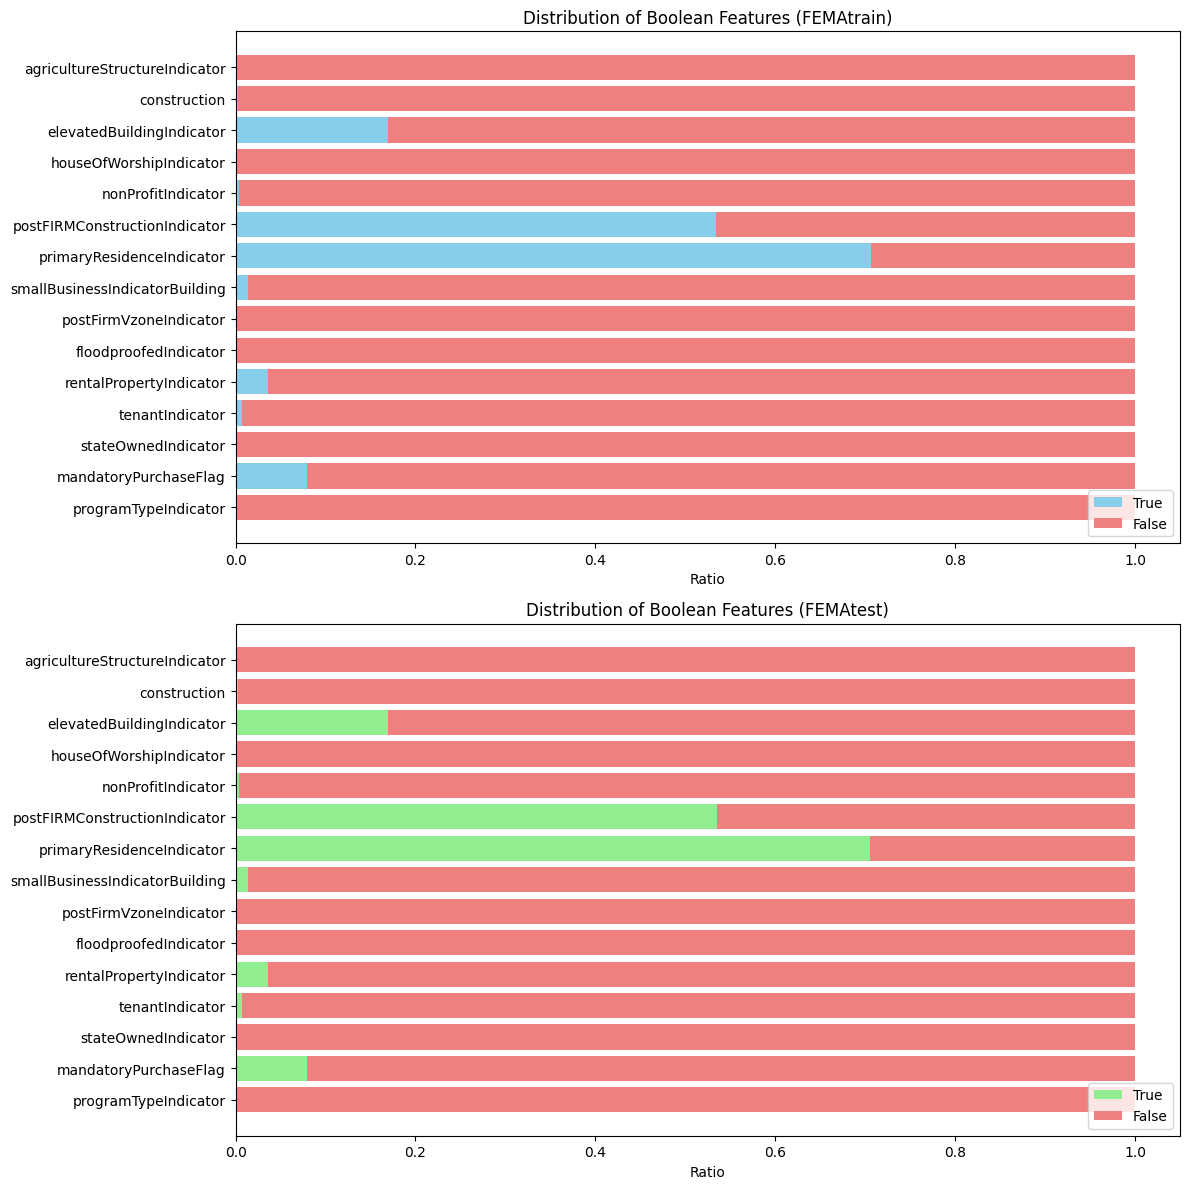

In [9]:
# Identify boolean columns
bool_cols = df_train.select_dtypes(include=['bool']).columns.tolist()

def get_bool_stats(df):
    summary = []
    for col in bool_cols:
        counts = df[col].value_counts(normalize=True)
        summary.append({
            'Column': col,
            'True_Ratio': counts.get(True, 0),
            'False_Ratio': counts.get(False, 0)
        })
    return pd.DataFrame(summary)

df_bool_train = get_bool_stats(df_train)
df_bool_test = get_bool_stats(df_test)

# Display summary statistics
print("Boolean feature distribution in FEMAtrain:")
display(df_bool_train)
print("\nBoolean feature distribution in FEMAtest:")
display(df_bool_test)

# Plotting horizontal stacked bar charts for both
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Train Plot (Horizontal)
ax1.barh(df_bool_train['Column'], df_bool_train['True_Ratio'], label='True', color='skyblue')
ax1.barh(df_bool_train['Column'], df_bool_train['False_Ratio'], left=df_bool_train['True_Ratio'], label='False', color='lightcoral')
ax1.set_title('Distribution of Boolean Features (FEMAtrain)')
ax1.set_xlabel('Ratio')
ax1.invert_yaxis()
ax1.legend(loc='lower right')

# Test Plot (Horizontal)
ax2.barh(df_bool_test['Column'], df_bool_test['True_Ratio'], label='True', color='lightgreen')
ax2.barh(df_bool_test['Column'], df_bool_test['False_Ratio'], left=df_bool_test['True_Ratio'], label='False', color='lightcoral')
ax2.set_title('Distribution of Boolean Features (FEMAtest)')
ax2.set_xlabel('Ratio')
ax2.invert_yaxis()
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [10]:
# Identify categorical columns
cat_cols = df_train.select_dtypes(include=['category']).columns.tolist()

print("Categorical features in FEMAtrain and FEMAtest:")
for col in cat_cols:
    print(f"\n--- {col} (FEMAtrain) ---")
    display(df_train[col].value_counts(normalize=True).head(10))
    print(f"\n--- {col} (FEMAtest) ---")
    display(df_test[col].value_counts(normalize=True).head(10))

Categorical features in FEMAtrain and FEMAtest:

--- condominiumCoverageTypeCode (FEMAtrain) ---


,proportion
condominiumCoverageTypeCode,
N,0.946984
U,0.034252
A,0.011711
L,0.005274
H,0.001780



--- condominiumCoverageTypeCode (FEMAtest) ---


,proportion
condominiumCoverageTypeCode,
N,0.947147
U,0.034196
A,0.011547
L,0.005335
H,0.001775



--- buildingDeductibleCode (FEMAtrain) ---


...

,proportion
reportedCity,
Currently Unavailable,1.0



--- reportedZipCode (FEMAtrain) ---


,proportion
reportedZipCode,
77573,0.003694
70065,0.003186
70003,0.002830
70072,0.002822
08008,0.002822
33908,0.002814
33914,0.002724
70458,0.002531
70001,0.002477



--- reportedZipCode (FEMAtest) ---


,proportion
reportedZipCode,
77573,0.003412
70065,0.003350
70072,0.002935
33914,0.002913
08008,0.002863
70003,0.002762
33908,0.002605
95835,0.002543
33186,0.002414


In [11]:
# Drop 'reportedCity' because it's unavailable
df_train.drop(columns=["reportedCity"], inplace=True)
df_test.drop(columns=["reportedCity"], inplace=True)
print("Dropped 'reportedCity' column from both df_train and df_test.")

Dropped 'reportedCity' column from both df_train and df_test.


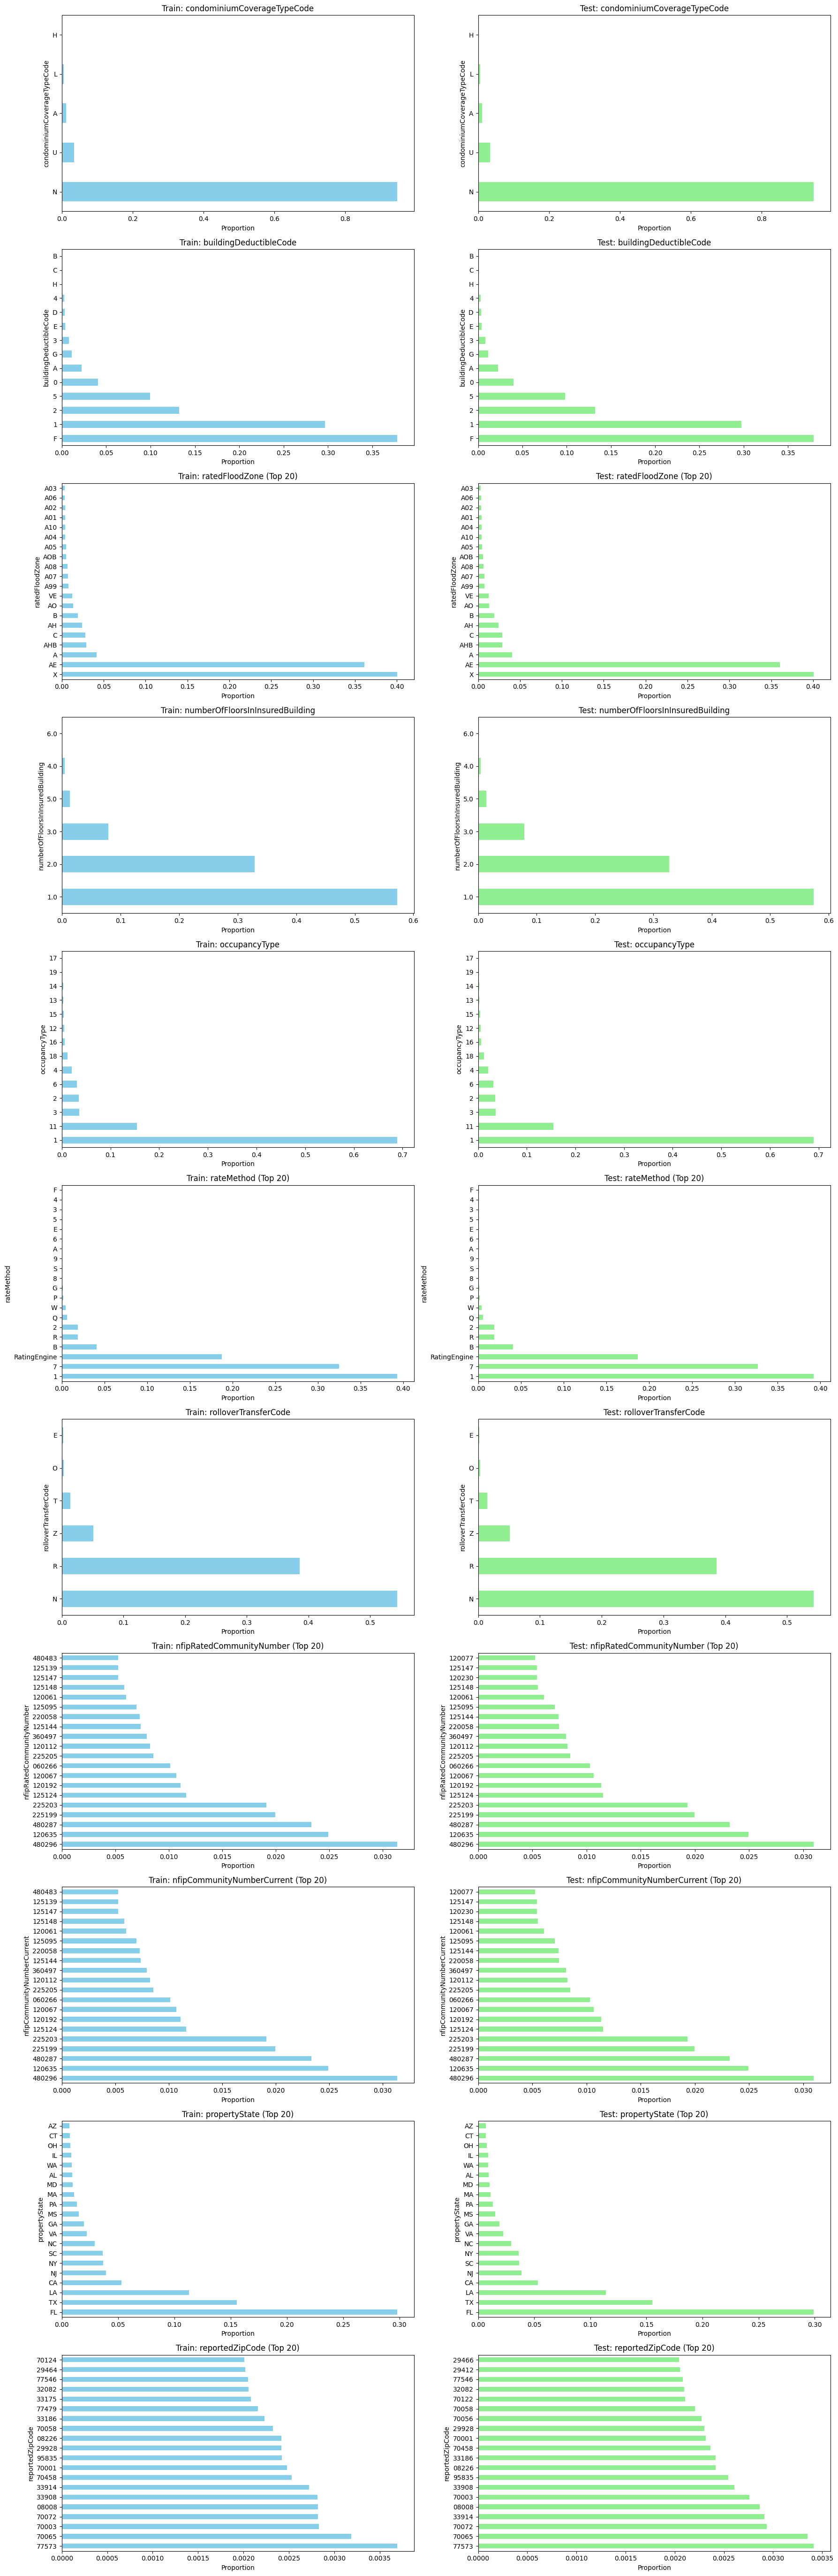

In [12]:
# Identify all categorical columns currently in the dataframe
cat_cols = df_train.select_dtypes(include=['category']).columns.tolist()

# Set up the figure for subplots: 2 columns (Train, Test) for each feature
n_features = len(cat_cols)
fig, axes = plt.subplots(n_features, 2, figsize=(18, 5 * n_features))

for i, col in enumerate(cat_cols):
    # Normalized counts (proportions)
    train_counts = df_train[col].value_counts(normalize=True).sort_values(ascending=False)
    test_counts = df_test[col].value_counts(normalize=True).sort_values(ascending=False)

    # Limit to top 20 for high-cardinality columns
    if len(train_counts) > 20:
        train_counts = train_counts.head(20)
        test_counts = test_counts.head(20)
        title_suffix = " (Top 20)"
    else:
        title_suffix = ""

    # Plot Train
    train_counts.plot(kind='barh', ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Train: {col}{title_suffix}')
    axes[i, 0].set_xlabel('Proportion')

    # Plot Test
    test_counts.plot(kind='barh', ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Test: {col}{title_suffix}')
    axes[i, 1].set_xlabel('Proportion')

plt.tight_layout()
plt.show()

In [13]:
# Identify date columns
date_cols = df_train.select_dtypes(include=['datetime64[ns]']).columns.tolist()

print("Date features summary statistics in FEMAtrain:")
display(df_train[date_cols].describe())

print("\nDate features summary statistics in FEMAtest:")
display(df_test[date_cols].describe())

Date features summary statistics in FEMAtrain:


,originalConstructionDate,originalNBDate,policyEffectiveDate,policyTerminationDate
count,356243,356756,356839,356839
mean,1981-04-12 23:18:55.884213824,2011-04-09 20:19:55.250535680,2017-01-01 07:01:37.808815616,2018-01-02 07:59:58.708661504
min,1730-06-01 00:00:00,1953-01-01 00:00:00,2009-01-01 00:00:00,2010-01-01 00:00:00
25%,1968-01-01 00:00:00,2007-02-10 00:00:00,2012-10-16 00:00:00,2013-10-17 00:00:00
50%,1983-05-02 00:00:00,2011-02-22 00:00:00,2016-10-17 00:00:00,2017-10-18 00:00:00
75%,2000-01-01 00:00:00,2016-04-08 00:00:00,2021-01-29 12:00:00,2022-01-30 00:00:00
max,2025-08-19 00:00:00,2025-10-18 00:00:00,2025-11-01 00:00:00,2028-09-20 00:00:00



Date features summary statistics in FEMAtest:


,originalConstructionDate,originalNBDate,policyEffectiveDate,policyTerminationDate
count,356116,356590,356675,356675
mean,1981-04-23 06:40:18.897213184,2011-03-30 17:14:23.640595968,2017-01-01 14:21:02.924510976,2018-01-02 13:30:02.255835136
min,1753-01-02 00:00:00,1940-07-01 00:00:00,2009-01-01 00:00:00,2010-01-01 00:00:00
25%,1968-01-01 00:00:00,2007-01-28 00:00:00,2012-10-18 00:00:00,2013-10-18 00:00:00
50%,1983-05-15 00:00:00,2011-02-09 00:00:00,2016-10-19 00:00:00,2017-10-19 00:00:00
75%,2000-01-01 00:00:00,2016-03-29 00:00:00,2021-01-18 00:00:00,2022-01-18 00:00:00
max,2025-08-27 00:00:00,2025-11-03 00:00:00,2025-11-03 00:00:00,2028-09-04 00:00:00


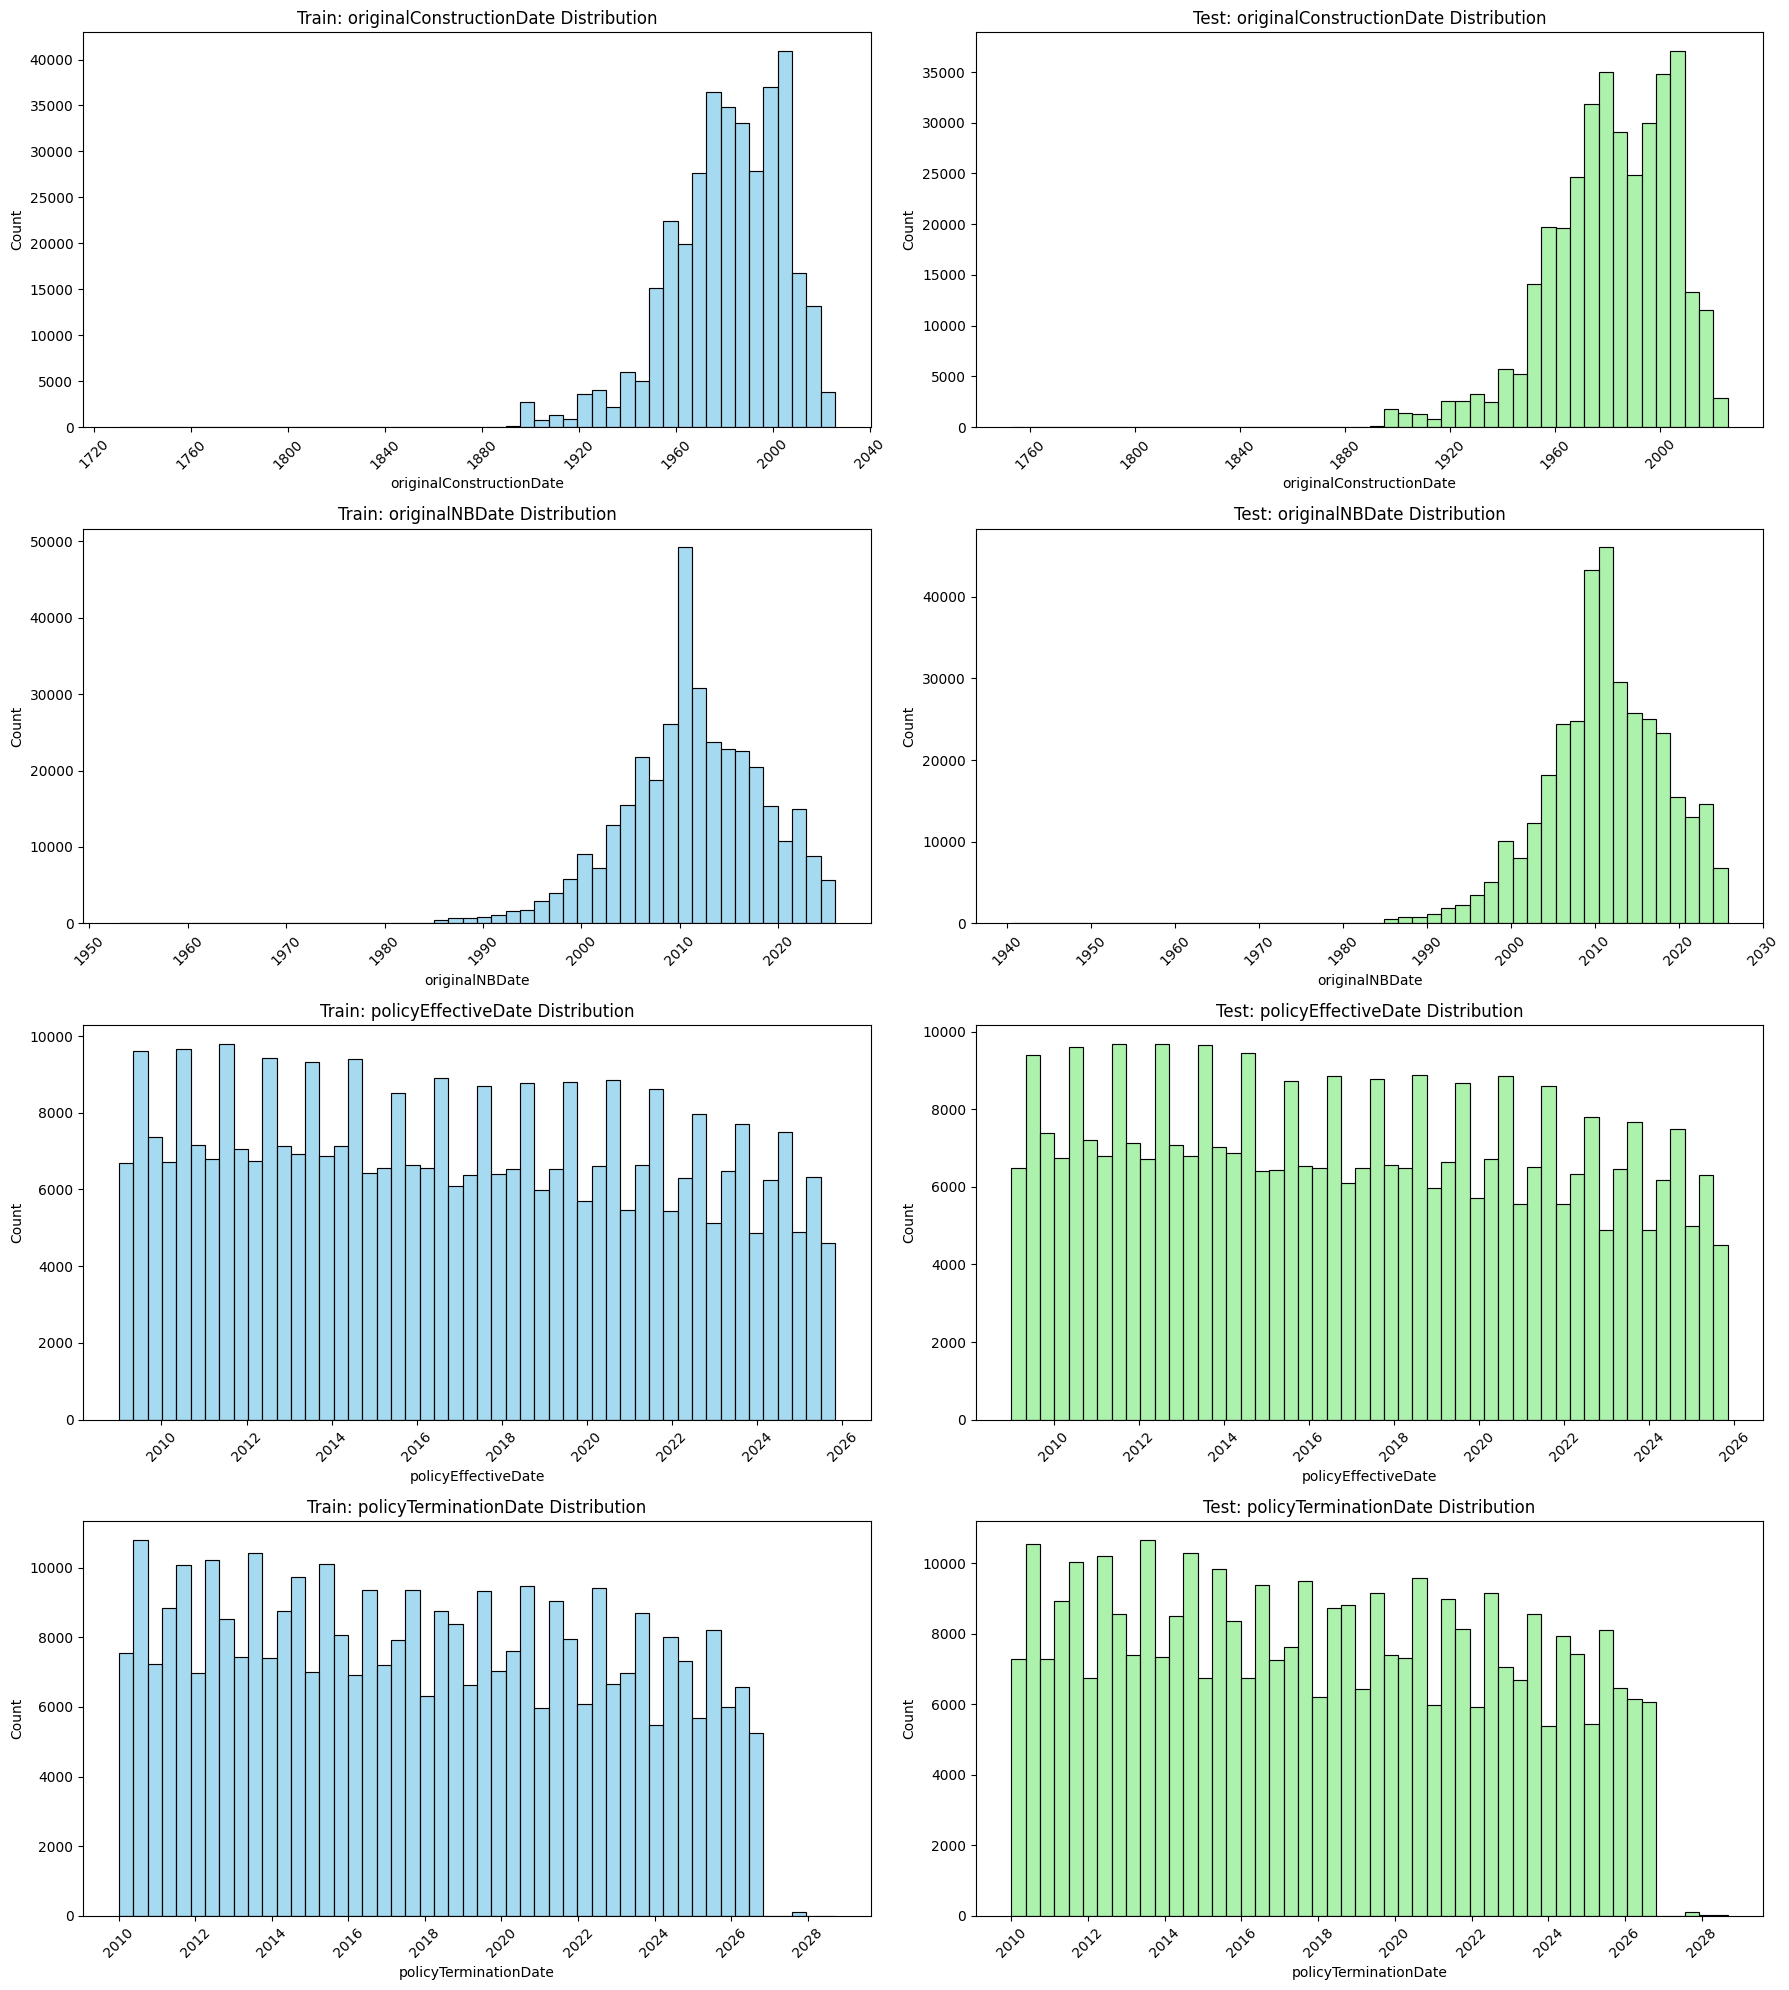

In [14]:
# Identify datetime columns
datetime_cols = ['originalConstructionDate', 'originalNBDate', 'policyEffectiveDate', 'policyTerminationDate']

# Set up the figure for subplots: 2 columns (Train, Test) for each date feature
n_dates = len(datetime_cols)
fig, axes = plt.subplots(n_dates, 2, figsize=(18, 5 * n_dates))

for i, col in enumerate(datetime_cols):
    # Plot Train Histogram
    sns.histplot(df_train[col].dropna(), bins=50, ax=axes[i, 0], color='skyblue', kde=False)
    axes[i, 0].set_title(f'Train: {col} Distribution')
    axes[i, 0].tick_params(axis='x', rotation=45)

    # Plot Test Histogram
    sns.histplot(df_test[col].dropna(), bins=50, ax=axes[i, 1], color='lightgreen', kde=False)
    axes[i, 1].set_title(f'Test: {col} Distribution')
    axes[i, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [15]:
# Identify numerical columns
num_cols = df_train.select_dtypes(include=np.number).columns.tolist()

print("Numerical features summary statistics in FEMAtrain:")
display(df_train[num_cols].describe())

print("\nNumerical features summary statistics in FEMAtest:")
display(df_test[num_cols].describe())

Numerical features summary statistics in FEMAtrain:


,federalPolicyFee,hfiaaSurcharge,policyCost,policyCount,policyTermIndicator,totalBuildingInsuranceCoverage,totalContentsInsuranceCoverage,totalInsurancePremiumOfThePolicy,iccPremium,reserveFundAssessment,buildingReplacementCost
count,356839.000000,356839.000000,356839.000000,356839.000000,356839.000000,3.568390e+05,356839.000000,356839.000000,353651.000000,356839.000000,3.393350e+05
mean,44.122531,53.945499,1031.531402,1.234153,1.002245,2.487775e+05,60786.829520,841.565322,18.232235,91.898049,4.567355e+05
std,84.078258,90.523001,1923.371695,5.108137,0.064991,1.021697e+06,61215.032989,1676.480058,23.617363,234.031840,5.091532e+06
min,-100.000000,-250.000000,-2915.000000,1.000000,1.000000,0.000000e+00,0.000000,-2495.000000,0.000000,-374.000000,0.000000e+00
25%,25.000000,0.000000,416.000000,1.000000,1.000000,1.500000e+05,6000.000000,345.000000,5.000000,0.000000,1.300000e+05
50%,40.000000,25.000000,587.000000,1.000000,1.000000,2.500000e+05,60000.000000,438.000000,6.000000,52.000000,2.220000e+05
75%,47.000000,25.000000,1041.000000,1.000000,1.000000,2.500000e+05,100000.000000,833.000000,20.000000,95.000000,2.930000e+05
max,2794.000000,500.000000,312418.000000,718.000000,3.000000,1.317500e+08,500000.000000,269711.000000,75.000000,40457.000000,1.633428e+09



Numerical features summary statistics in FEMAtest:


,federalPolicyFee,hfiaaSurcharge,policyCost,policyCount,policyTermIndicator,totalBuildingInsuranceCoverage,totalContentsInsuranceCoverage,totalInsurancePremiumOfThePolicy,iccPremium,reserveFundAssessment,buildingReplacementCost
count,356675.000000,356675.000000,356675.000000,356675.000000,356675.000000,3.566750e+05,356675.000000,356675.000000,353524.000000,356675.000000,3.390010e+05
mean,44.111998,54.224625,1030.798646,1.237536,1.001979,2.504971e+05,60893.550151,840.669741,18.126113,91.792281,4.770834e+05
std,85.527933,90.759588,1898.125333,4.991964,0.060618,1.063369e+06,61913.359056,1631.770482,23.522419,243.123255,7.196613e+06
min,-100.000000,-200.000000,-482.000000,1.000000,1.000000,0.000000e+00,0.000000,-178.000000,0.000000,-2359.000000,0.000000e+00
25%,25.000000,0.000000,414.000000,1.000000,1.000000,1.500000e+05,6000.000000,345.000000,5.000000,0.000000,1.300000e+05
50%,40.000000,25.000000,584.000000,1.000000,1.000000,2.500000e+05,60000.000000,438.000000,6.000000,52.000000,2.200000e+05
75%,47.000000,25.000000,1042.000000,1.000000,1.000000,2.500000e+05,100000.000000,832.000000,19.000000,95.000000,2.920000e+05
max,2480.000000,500.000000,197084.000000,562.000000,3.000000,1.370000e+08,500000.000000,169421.000000,75.000000,28106.000000,2.147484e+09


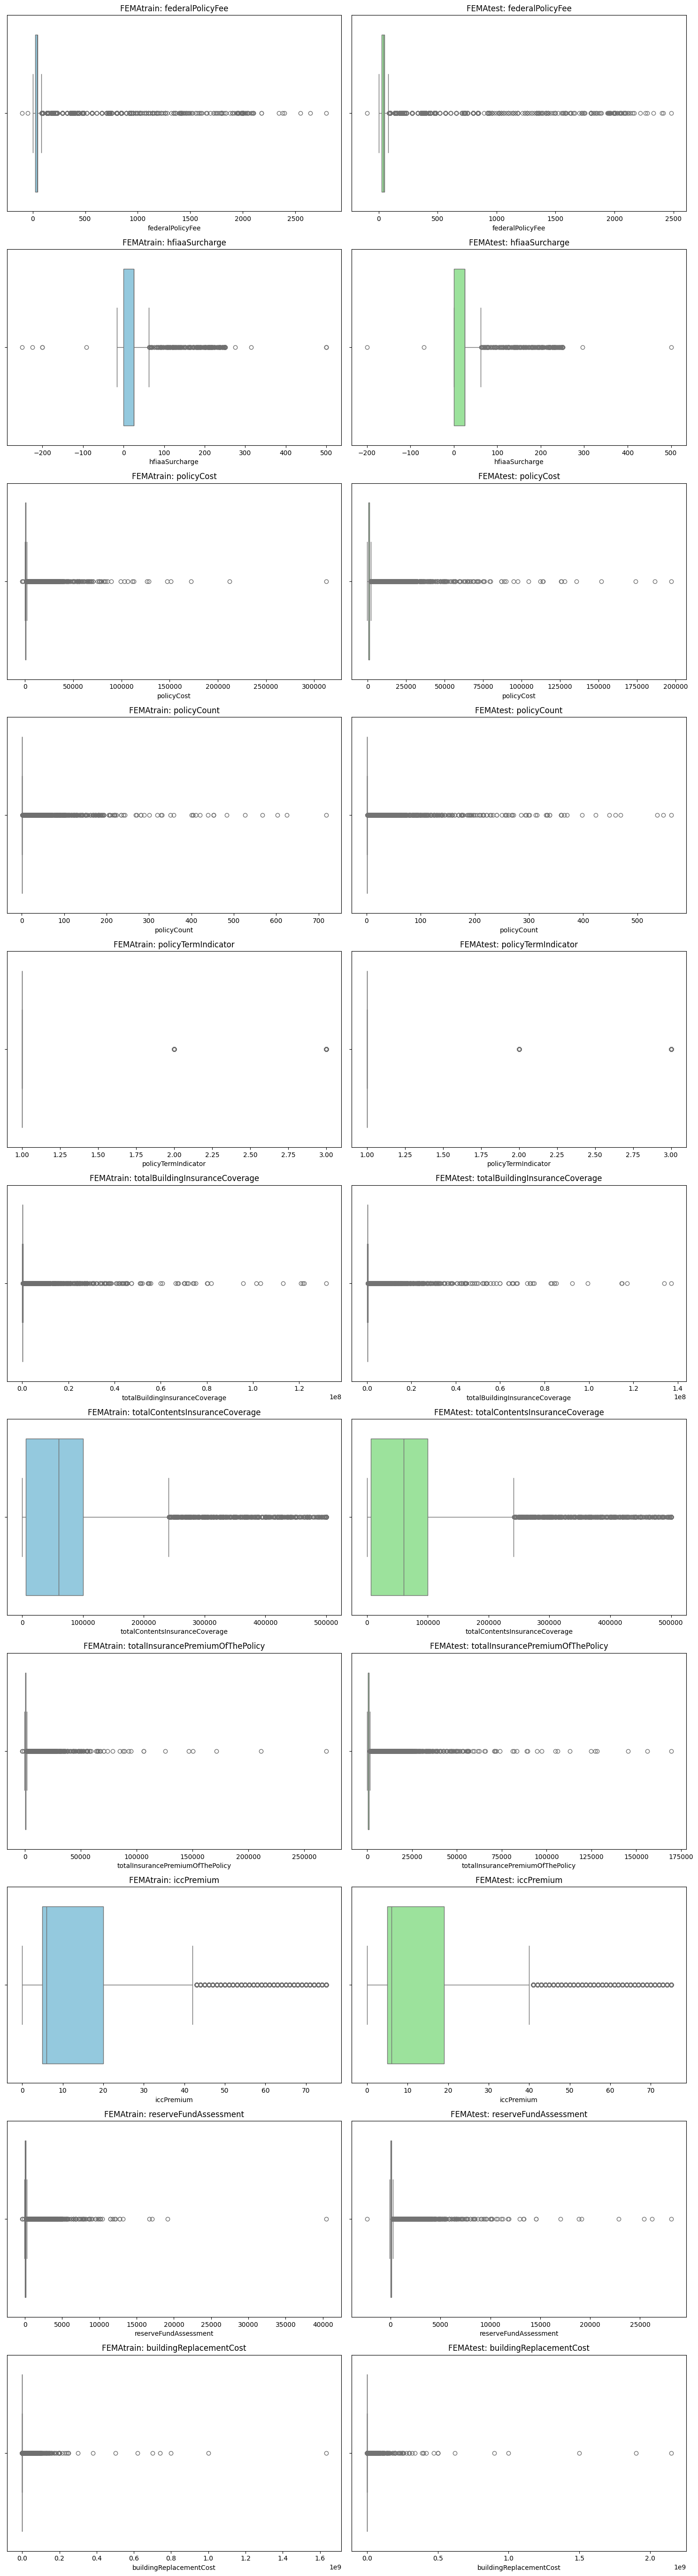

In [16]:
# Identify numerical columns
num_cols = df_train.select_dtypes(include=np.number).columns.tolist()

# Set up the figure for subplots
n_cols = len(num_cols)
fig, axes = plt.subplots(n_cols, 2, figsize=(15, 5 * n_cols))

for i, col in enumerate(num_cols):
    # Plot for df_train
    sns.boxplot(x=df_train[col], ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'FEMAtrain: {col}')

    # Plot for df_test
    sns.boxplot(x=df_test[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'FEMAtest: {col}')

plt.tight_layout()
plt.show()

Most "outliers" (according to Tukey's method) don't seem horribly out of place compared to the rest of the data. `policyTermIndicator` only takes 1, 2, and 3 as values, so no issues there.

I'll take a look at the training data's biggest outliers in `policyCost` (over 300000) and `reserveFundAssessment` (over 40000), since they appear well beyond any of the other values in either dataset

In [17]:
# Filter df_train for policyCost outliers
policy_cost_outliers = df_train[df_train['policyCost'] > 300000]

print("Outliers in FEMAtrain where policyCost > 300000:")
display(policy_cost_outliers.head())

Outliers in FEMAtrain where policyCost > 300000:


,agricultureStructureIndicator,condominiumCoverageTypeCode,construction,buildingDeductibleCode,elevatedBuildingIndicator,federalPolicyFee,ratedFloodZone,hfiaaSurcharge,houseOfWorshipIndicator,nonProfitIndicator,...,rentalPropertyIndicator,tenantIndicator,stateOwnedIndicator,mandatoryPurchaseFlag,nfipRatedCommunityNumber,nfipCommunityNumberCurrent,programTypeIndicator,propertyState,reportedZipCode,id
241252,False,A,False,2,False,2000,AE,250,False,False,...,True,False,False,False,120651,120651,False,FL,33139,b'\xceB\xb2\x1a\toF\xfb\xb7.\xab\xef\xa52\xf3\...


In [18]:
# Filter df_train for reserveFundAssessment outliers
reserve_fund_outliers = df_train[df_train['reserveFundAssessment'] > 40000]

print("Outliers in FEMAtrain where reserveFundAssessment > 40000:")
display(reserve_fund_outliers.head())

Outliers in FEMAtrain where reserveFundAssessment > 40000:


,agricultureStructureIndicator,condominiumCoverageTypeCode,construction,buildingDeductibleCode,elevatedBuildingIndicator,federalPolicyFee,ratedFloodZone,hfiaaSurcharge,houseOfWorshipIndicator,nonProfitIndicator,...,rentalPropertyIndicator,tenantIndicator,stateOwnedIndicator,mandatoryPurchaseFlag,nfipRatedCommunityNumber,nfipCommunityNumberCurrent,programTypeIndicator,propertyState,reportedZipCode,id
241252,False,A,False,2,False,2000,AE,250,False,False,...,True,False,False,False,120651,120651,False,FL,33139,b'\xceB\xb2\x1a\toF\xfb\xb7.\xab\xef\xa52\xf3\...


It's the same row! I'll investigate it further.

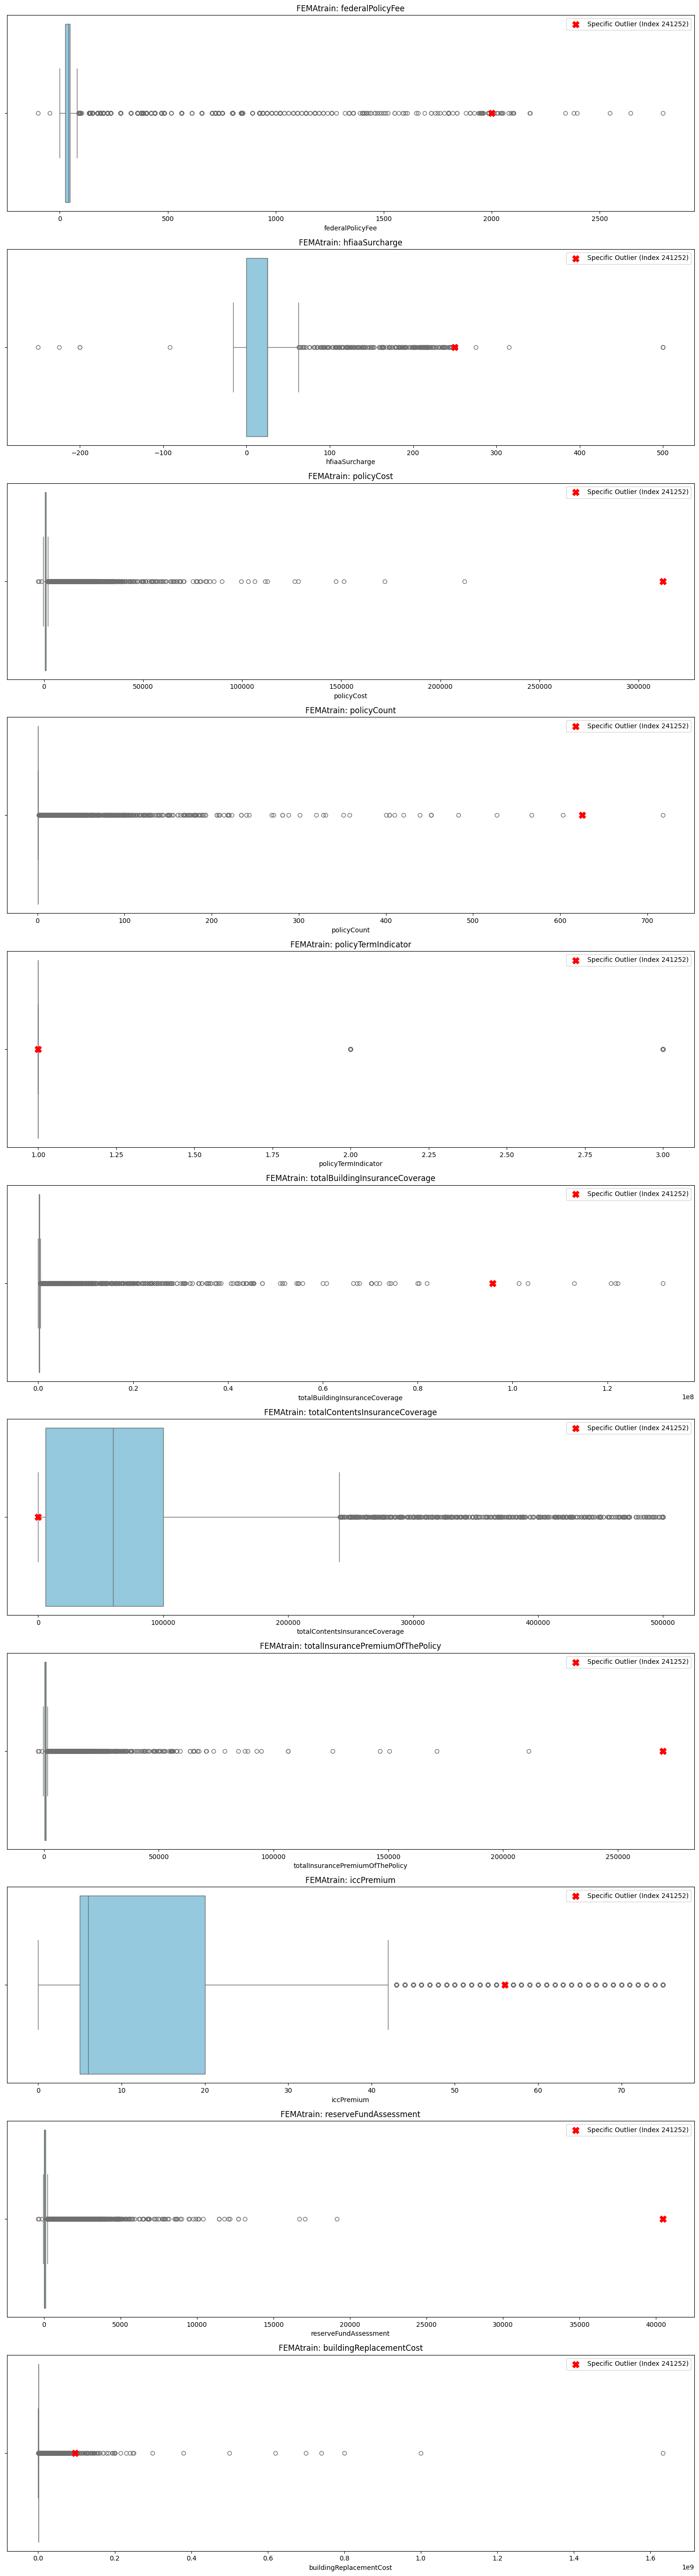

In [19]:
# Identify numerical columns (assume num_cols is available)
# In this specific case, num_cols is already available from previous execution context.
# num_cols = df_train.select_dtypes(include=np.number).columns.tolist()

# Define the index of the specific outlier row
outlier_index = 241252

# Set up the figure for subplots, one column for df_train only
n_cols = len(num_cols)
fig, axes = plt.subplots(n_cols, 1, figsize=(15, 5 * n_cols))

# Ensure axes is an array even if n_cols is 1
if n_cols == 1:
    axes = [axes]

for i, col in enumerate(num_cols):
    # Plot boxplot for df_train. Do not use flierprops here, as we will explicitly mark the single outlier.
    sns.boxplot(x=df_train[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'FEMAtrain: {col}')

    # Get the value for the specific outlier row in the current column
    # Check if the column contains the outlier_index, as some columns might have NaN at this index after previous operations
    if outlier_index in df_train.index and col in df_train.columns:
        specific_outlier_value = df_train.loc[outlier_index, col]
        # Mark the specific outlier
        # Use a distinct marker to make it clear it's *the* specific outlier
        axes[i].scatter(specific_outlier_value, 0, color='red', marker='X', s=100, zorder=5, label=f'Specific Outlier (Index {outlier_index})')
        axes[i].legend()

plt.tight_layout()
plt.show()

In [20]:
outlier_index = 241252

# Identify numerical columns (assuming num_cols is still defined from previous steps)
# If num_cols is not defined, uncomment and run the following line:
# num_cols = df_train.select_dtypes(include=np.number).columns.tolist()

# Display the specific outlier row for numerical columns
print(f"Details of the specific outlier row (index {outlier_index}) in FEMAtrain:\n")
display(df_train.loc[[outlier_index], num_cols])

Details of the specific outlier row (index 241252) in FEMAtrain:



,federalPolicyFee,hfiaaSurcharge,policyCost,policyCount,policyTermIndicator,totalBuildingInsuranceCoverage,totalContentsInsuranceCoverage,totalInsurancePremiumOfThePolicy,iccPremium,reserveFundAssessment,buildingReplacementCost
241252,2000,250,312418,625,1,95755600,0,269711,56.0,40457,95755600.0


I can't be sure if anything's wrong with this outlier, so I'll leave it in for now.

Now among rows with missing values, which do I drop/impute?

I know that I coerced many dates into NaT because they were too old. These dates are quite extreme and should not be imputed with the median, so I'll drop rows with missing dates.

In [21]:
# Identify date columns for dropping NaT values
date_cols_to_check = ['originalConstructionDate', 'originalNBDate', 'policyEffectiveDate', 'policyTerminationDate']

# Drop rows with NaT in any of the specified date columns for df_train
initial_rows_train = len(df_train)
df_train.dropna(subset=date_cols_to_check, inplace=True)
dropped_rows_train = initial_rows_train - len(df_train)
print(f"Dropped {dropped_rows_train} rows from df_train due to missing dates.")

# Drop rows with NaT in any of the specified date columns for df_test
initial_rows_test = len(df_test)
df_test.dropna(subset=date_cols_to_check, inplace=True)
dropped_rows_test = initial_rows_test - len(df_test)
print(f"Dropped {dropped_rows_test} rows from df_test due to missing dates.")

Dropped 679 rows from df_train due to missing dates.
Dropped 644 rows from df_test due to missing dates.


I'll impute the rest with the median (if date/numerical) or mode (if boolean/categorical).

In [22]:
print("Imputing missing values in boolean columns with mode...")
for col in bool_cols:
    if df_train[col].isna().any():
        mode_train = df_train[col].mode()[0]
        df_train[col] = df_train[col].fillna(mode_train)
        print(f"df_train: Imputed boolean column '{col}' with mode: {mode_train}")
    if df_test[col].isna().any():
        mode_test = df_test[col].mode()[0]
        df_test[col] = df_test[col].fillna(mode_test)
        print(f"df_test: Imputed boolean column '{col}' with mode: {mode_test}")

print("\nImputing missing values in categorical columns with mode...")
for col in cat_cols:
    if df_train[col].isna().any():
        mode_train = df_train[col].mode()[0]
        df_train[col] = df_train[col].fillna(mode_train)
        print(f"df_train: Imputed categorical column '{col}' with mode: {mode_train}")
    if df_test[col].isna().any():
        mode_test = df_test[col].mode()[0]
        df_test[col] = df_test[col].fillna(mode_test)
        print(f"df_test: Imputed categorical column '{col}' with mode: {mode_test}")

# Verify that there are no more missing values in these columns after imputation
print("\nVerifying missing values in boolean columns after imputation:")
for col in bool_cols:
    print(f"df_train['{col}'] missing: {df_train[col].isna().sum()}")
    print(f"df_test['{col}'] missing: {df_test[col].isna().sum()}")

print("\nVerifying missing values in categorical columns after imputation:")
for col in cat_cols:
    print(f"df_train['{col}'] missing: {df_train[col].isna().sum()}")
    print(f"df_test['{col}'] missing: {df_test[col].isna().sum()}")

Imputing missing values in boolean columns with mode...

Imputing missing values in categorical columns with mode...
df_train: Imputed categorical column 'condominiumCoverageTypeCode' with mode: N
df_test: Imputed categorical column 'condominiumCoverageTypeCode' with mode: N
df_train: Imputed categorical column 'buildingDeductibleCode' with mode: F
df_test: Imputed categorical column 'buildingDeductibleCode' with mode: F
df_train: Imputed categorical column 'ratedFloodZone' with mode: X
df_test: Imputed categorical column 'ratedFloodZone' with mode: X
df_train: Imputed categorical column 'rolloverTransferCode' with mode: N
df_test: Imputed categorical column 'rolloverTransferCode' with mode: N

Verifying missing values in boolean columns after imputation:
df_train['agricultureStructureIndicator'] missing: 0
df_test['agricultureStructureIndicator'] missing: 0
df_train['construction'] missing: 0
df_test['construction'] missing: 0
df_train['elevatedBuildingIndicator'] missing: 0
df_test['

In [23]:
print("Imputing missing values in numerical columns with median...")
for col in num_cols:
    if df_train[col].isna().any():
        median_train = df_train[col].median()
        df_train[col] = df_train[col].fillna(median_train)
        print(f"df_train: Imputed numerical column '{col}' with median: {median_train}")
    if df_test[col].isna().any():
        median_test = df_test[col].median()
        df_test[col] = df_test[col].fillna(median_test)
        print(f"df_test: Imputed numerical column '{col}' with median: {median_test}")

print("\nImputing missing values in date columns with median...")
for col in date_cols:
    if df_train[col].isna().any():
        median_train = df_train[col].median()
        df_train[col] = df_train[col].fillna(median_train)
        print(f"df_train: Imputed date column '{col}' with median: {median_train}")
    if df_test[col].isna().any():
        median_test = df_test[col].median()
        df_test[col] = df_test[col].fillna(median_test)
        print(f"df_test: Imputed date column '{col}' with median: {median_test}")

# Verify that there are no more missing values in these columns after imputation
print("\nVerifying missing values in numerical columns after imputation:")
for col in num_cols:
    print(f"df_train['{col}'] missing: {df_train[col].isna().sum()}")
    print(f"df_test['{col}'] missing: {df_test[col].isna().sum()}")

print("\nVerifying missing values in date columns after imputation:")
for col in date_cols:
    print(f"df_train['{col}'] missing: {df_train[col].isna().sum()}")
    print(f"df_test['{col}'] missing: {df_test[col].isna().sum()}")

Imputing missing values in numerical columns with median...
df_train: Imputed numerical column 'iccPremium' with median: 6.0
df_test: Imputed numerical column 'iccPremium' with median: 6.0
df_train: Imputed numerical column 'buildingReplacementCost' with median: 222000.0
df_test: Imputed numerical column 'buildingReplacementCost' with median: 220000.0

Imputing missing values in date columns with median...

Verifying missing values in numerical columns after imputation:
df_train['federalPolicyFee'] missing: 0
df_test['federalPolicyFee'] missing: 0
df_train['hfiaaSurcharge'] missing: 0
df_test['hfiaaSurcharge'] missing: 0
df_train['policyCost'] missing: 0
df_test['policyCost'] missing: 0
df_train['policyCount'] missing: 0
df_test['policyCount'] missing: 0
df_train['policyTermIndicator'] missing: 0
df_test['policyTermIndicator'] missing: 0
df_train['totalBuildingInsuranceCoverage'] missing: 0
df_test['totalBuildingInsuranceCoverage'] missing: 0
df_train['totalContentsInsuranceCoverage'] 

In [24]:
print(f"Total missing values in df_train after imputation: {df_train.isna().sum().sum()}")
print(f"Total missing values in df_test after imputation: {df_test.isna().sum().sum()}")

Total missing values in df_train after imputation: 0
Total missing values in df_test after imputation: 0


In [25]:
df_train.to_parquet('clean_train.parquet', index=False)
df_test.to_parquet('clean_test.parquet', index=False)

print("df_train saved to clean_train.parquet")
print("df_test saved to clean_test.parquet")

df_train saved to clean_train.parquet
df_test saved to clean_test.parquet
